In [ ]:
import zipfile
import os
import pandas as pd

# Define the path to the zip file
zip_file_path = '/content/archive (1).zip'

# Define the directory to extract contents to
extract_dir = '/content/extracted_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f'Zip file extracted to: {extract_dir}')

Zip file extracted to: /content/extracted_data


In [8]:
import pandas as pd

# 1. Load the dataset using the correct file path
df = pd.read_csv('/content/extracted_data/retail_sales_dataset.csv')

# 2. Show the first 5 rows to see the data
print(df.head())

# 3. Check for missing values
print(df.isnull().sum())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [9]:
# 1. Convert the 'Date' column to a proper datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 2. View basic statistics (like average age, min/max sales)
print("Basic Statistics:")
print(df.describe())

# 3. Calculate the total overall revenue
total_revenue = df['Total Amount'].sum()
print(f"\nTotal Revenue: ${total_revenue}")

Basic Statistics:
       Transaction ID                           Date         Age     Quantity  \
count     1000.000000                           1000  1000.00000  1000.000000   
mean       500.500000  2023-07-03 00:25:55.200000256    41.39200     2.514000   
min          1.000000            2023-01-01 00:00:00    18.00000     1.000000   
25%        250.750000            2023-04-08 00:00:00    29.00000     1.000000   
50%        500.500000            2023-06-29 12:00:00    42.00000     3.000000   
75%        750.250000            2023-10-04 00:00:00    53.00000     4.000000   
max       1000.000000            2024-01-01 00:00:00    64.00000     4.000000   
std        288.819436                            NaN    13.68143     1.132734   

       Price per Unit  Total Amount  
count     1000.000000   1000.000000  
mean       179.890000    456.000000  
min         25.000000     25.000000  
25%         30.000000     60.000000  
50%         50.000000    135.000000  
75%        300.000000   

/tmp/ipykernel_463/3452593722.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Product Category', y='Total Amount', palette='viridis')


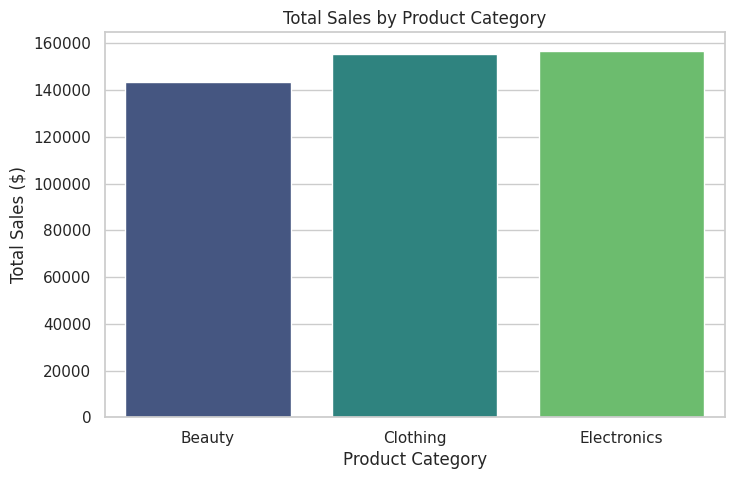

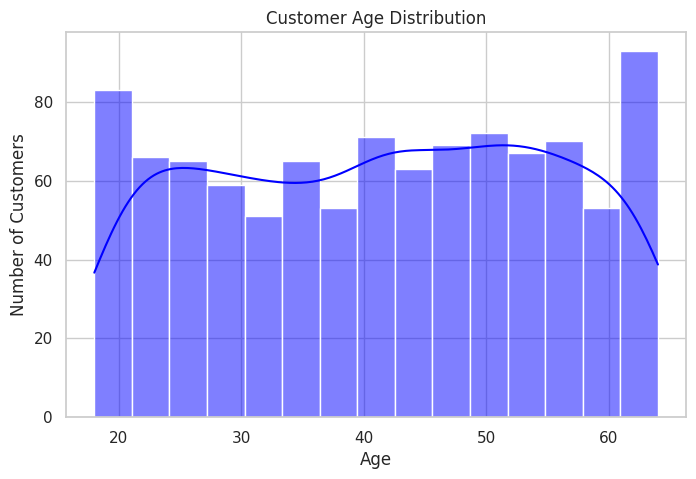

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the charts
sns.set_theme(style="whitegrid")

# Chart 1: Total Sales by Product Category
plt.figure(figsize=(8, 5))
category_sales = df.groupby('Product Category')['Total Amount'].sum().reset_index()
sns.barplot(data=category_sales, x='Product Category', y='Total Amount', palette='viridis')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales ($)')
plt.show()

# Chart 2: Customer Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=15, kde=True, color='blue')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

In [11]:
# 1. Live Analysis: Which category generated the highest sales?
top_category = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
print("--- Sales by Category ---")
print(top_category)

# 2. Live Analysis: Average spend by Gender
avg_spend = df.groupby('Gender')['Total Amount'].mean()
print("\n--- Average Spend by Gender ---")
print(avg_spend)

--- Sales by Category ---
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

--- Average Spend by Gender ---
Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64


In [12]:
%%writefile README.md
# Retail Sales Data Analytics Project

## Project Overview
This project analyzes a retail sales dataset to uncover insights into customer purchasing behavior, demographics, and product performance. It is part of the AICTE | IBM SkillsBuild Data Analytics internship.

## Dataset
The dataset contains 1,000 transaction records, including features like Customer ID, Age, Gender, Product Category, Quantity, Price, and Total Amount.

## Technologies Used
- Python (Pandas, Matplotlib, Seaborn)
- Jupyter Notebook / Google Colab

## Key Insights
- **Total Revenue:** $456,000
- **Top Selling Category:** Electronics ($156,905)
- **Average Spend:** Female ($456.55) and Male ($455.43) customers spent almost equally on average.


Writing README.md


In [ ]:
# List the contents of the extracted directory
extracted_files = os.listdir(extract_dir)
print('Contents of extracted directory:')
for f in extracted_files:
    print(f)


Contents of extracted directory:
retail_sales_dataset.csv


Based on the typical names for data files in such archives, I will assume the main dataset is in `google_review_ratings.csv`. If this is not the correct file, please let me know which file you'd like to load.

In [ ]:
# Assuming the main data file is 'retail_sales_dataset.csv'
data_file_path = os.path.join(extract_dir, 'retail_sales_dataset.csv')

# Load the CSV into a pandas DataFrame
df = pd.read_csv(data_file_path)

# Display the first 5 rows of the DataFrame
print('First 5 rows of the DataFrame:')
display(df.head())

First 5 rows of the DataFrame:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
